# Лабораторная работа №1. Один текст - разные представления

**Курс:** Автоматическая обработка текстов

**Автор:** Мещеряков Даниил Павлович, ИСУ 409130

**Преподаватель:** Гусарова Наталия Федоровна

**Цель:** исследовать, какие свойства текста сохраняются и теряются при переходе от текста к вычислительному представлению.

**Данные.** Корпус RuSentiment (посты «ВКонтакте», COLING 2018). Из официального репозитория
`text-machine-lab/rusentiment` данные удалены по требованию VK, поэтому используется
оригинальный файл `rusentiment_preselected_posts.csv` с зеркала Hugging Face
(`VladEk123/rusentiment`). В файле есть столбцы `label, text`; столбец `id` добавляется как номер строки
в исходном файле.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from razdel import tokenize, sentenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
from transformers.utils import logging as hf_logging
from huggingface_hub.utils import logging as hub_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar(); hub_logging.set_verbosity_error()
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

SEED = 409130
DATA_URL = ("https://huggingface.co/datasets/VladEk123/rusentiment/"
            "resolve/main/rusentiment_preselected_posts.csv")
DATA_PATH = Path("data/rusentiment_preselected_posts.csv")
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

## 1. Загрузка данных и формирование выборки

In [2]:
if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(exist_ok=True)
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)

full = pd.read_csv(DATA_PATH)
full.insert(0, "id", np.arange(len(full)))
full = full[["id", "text", "label"]]
full["text"] = (full["text"].str.replace("\u0451", "е").str.replace("\u0401", "Е")
                .str.replace("[\u2014\u2013]", "-", regex=True))
print(full.shape)
full["label"].value_counts()

(6950, 3)


label
neutral     2977
positive    1475
negative    1360
skip         904
speech       234
Name: count, dtype: int64

Выборка: по 30 текстов каждого из 5 классов (`positive`, `negative`, `neutral`, `speech`, `skip`) - всего 150 текстов,
стратифицированно, `random_state = 409130`. Три текста, которые дальше будут модифицироваться, принудительно
включаются в выборку (каждый заменяет случайный текст своего класса), чтобы они участвовали в обучении BoW / TF-IDF.

In [3]:
CHOSEN = {
    "positive": "Хочется лета. Тупо болтаться на улице",
    "negative": "В школе на первых двух уроках хочется спать",
    "neutral":  "Купили ребенку селфи-палку",
}
chosen_ids = {lab: int(full[full["text"].str.startswith(prefix)]["id"].iloc[0])
              for lab, prefix in CHOSEN.items()}
print(chosen_ids)

sample = full.groupby("label").sample(30, random_state=SEED)
for lab, cid in chosen_ids.items():
    if cid not in sample["id"].values:
        victim = sample[sample["label"] == lab].index[0]
        sample = sample.drop(victim)
        sample = pd.concat([sample, full[full["id"] == cid]])
sample = sample.sort_values("id").reset_index(drop=True)
sample.to_csv(OUT_DIR / "sample_150.csv", index=False)
print(sample.shape)
sample["label"].value_counts()

{'positive': 2210, 'negative': 921, 'neutral': 3812}
(150, 3)


label
neutral     30
negative    30
skip        30
positive    30
speech      30
Name: count, dtype: int64

## 2. Проверка данных: пропуски, дубликаты, длины

In [4]:
def check(df, name):
    print(f"--- {name}: {len(df)} строк")
    print("пропуски:", df[["text", "label"]].isna().sum().to_dict())
    print("пустые тексты:", (df["text"].fillna("").str.strip() == "").sum())
    print("полные дубликаты (text+label):", df.duplicated(["text", "label"]).sum())
    print("дубликаты текста:", df.duplicated("text").sum())
    norm = df["text"].fillna("").str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    print("дубликаты после нормализации (регистр/пробелы):", norm.duplicated().sum())

check(full, "весь корпус")
check(sample, "выборка")

--- весь корпус: 6950 строк
пропуски: {'text': 0, 'label': 0}
пустые тексты: 0
полные дубликаты (text+label): 0
дубликаты текста: 0
дубликаты после нормализации (регистр/пробелы): 8
--- выборка: 150 строк
пропуски: {'text': 0, 'label': 0}
пустые тексты: 0
полные дубликаты (text+label): 0
дубликаты текста: 0
дубликаты после нормализации (регистр/пробелы): 0


In [5]:
key = full["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
full[key.duplicated(keep=False)].assign(key=key).sort_values("key")[["id", "text", "label"]]

,id,text,label
2115,2115,"Каждому человеку, которому ты даришь доверие, ты даешь в руки нож. Им он может тебя защитить или уничтожить.",neutral
3477,3477,"Каждому человеку, которому ты даришь доверие, ты даешь\n в руки нож. Им он может тебя защитить или уничтожить.",neutral
3580,3580,Как то так,neutral
3704,3704,как то так,neutral
3595,3595,Как-то так,neutral
3729,3729,как-то так,neutral
3154,3154,ну как-то так...,neutral
4413,4413,Ну как-то так...,neutral
332,332,Сессия закрыта!,positive
1961,1961,сессия закрыта!,positive


In [6]:
def words(text):
    return [t.text.lower() for t in tokenize(text) if re.search(r"\w", t.text)]

for df in (full, sample):
    df["n_chars"] = df["text"].str.len()
    df["n_words"] = df["text"].map(lambda t: len(words(t)))
    df["n_sents"] = df["text"].map(lambda t: len(list(sentenize(t))))

sample.groupby("label")[["n_chars", "n_words", "n_sents"]].describe().T.round(1)

label          negative  neutral  positive   skip  speech
n_chars count      30.0     30.0      30.0   30.0    30.0
        mean      107.1     99.6      69.9  156.2   154.9
        std       141.8    112.6      94.5  199.5   117.7
        min        14.0     13.0      11.0   11.0    18.0
        25%        31.8     30.5      31.0   28.8    67.0
        50%        69.5     65.5      49.5   72.5   114.0
        75%        96.5    110.8      81.2  145.8   214.8
        max       634.0    515.0     546.0  744.0   531.0
n_words count      30.0     30.0      30.0   30.0    30.0
        mean       17.6     15.9      11.0   25.9    24.1
        std        22.0     17.2      15.9   34.6    20.0
        min         1.0      2.0       2.0    1.0     2.0
        25%         5.2      5.0       5.0    4.0    10.0
        50%        11.0     11.5       7.0   11.5    20.0
        75%        18.5     18.0      10.0   28.5    34.2
        max        95.0     69.0      91.0  134.0    91.0
n_sents count      30.0     30.0      30.0   30.0    30.0
        mean        2.4      1.8       1.6    2.3     2.4
        std         2.6      1.6       1.6    2.5     2.0
        min         1.0      1.0       1.0    1.0     1.0
        25%         1.0      1.0       1.0    1.0     1.0
        50%         1.0      1.0       1.0    1.0     2.0
        75%         3.0      2.0       1.0    2.0     3.5
        max        12.0      7.0       9.0   10.0     9.0

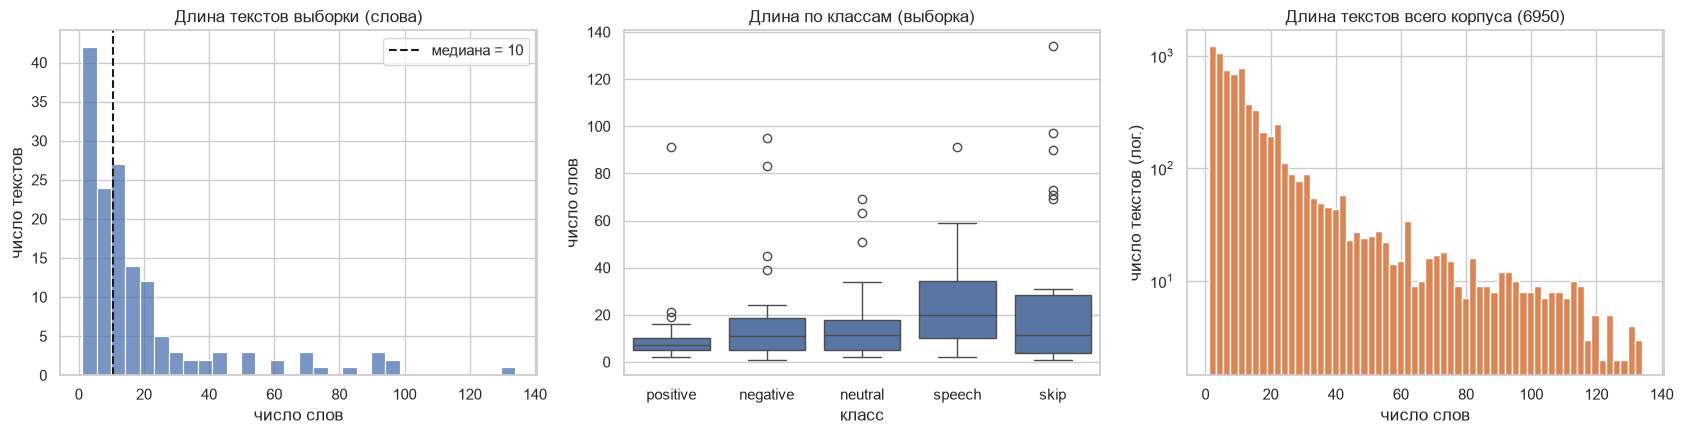

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(sample["n_words"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].axvline(sample["n_words"].median(), color="k", ls="--", label=f"медиана = {sample['n_words'].median():.0f}")
axes[0].set(title="Длина текстов выборки (слова)", xlabel="число слов", ylabel="число текстов"); axes[0].legend()

sns.boxplot(data=sample, x="label", y="n_words", ax=axes[1],
            order=["positive", "negative", "neutral", "speech", "skip"])
axes[1].set(title="Длина по классам (выборка)", xlabel="класс", ylabel="число слов")

axes[2].hist(full["n_words"], bins=60, color="#DD8452", edgecolor="white"); axes[2].set_yscale("log")
axes[2].set(title="Длина текстов всего корпуса (6950)", xlabel="число слов", ylabel="число текстов (лог.)")
plt.tight_layout(); plt.savefig(OUT_DIR / "length_distribution.png", dpi=150); plt.show()

## 3. Модифицированные тексты

Для каждого из трех исходных текстов создано три варианта:
1. **перестановка** - слов внутри предложения или самих предложений, без намеренного изменения смысла;
2. **парафраз** - тот же смысл, другими словами;
3. **смысловое изменение** - меняется смыслообразующий элемент (добавление отрицания / замена ключевого слова).

В столбце `meaning_changed` - мое ручное суждение о том, изменился ли смысл, в `justification` - обоснование.

In [8]:
orig = full.set_index("id").loc[list(chosen_ids.values()), ["text", "label"]]
for i, r in orig.iterrows():
    print(f"[{r.label}] id={i}\n{r.text}\n")

[positive] id=2210
Хочется лета. Тупо болтаться на улице, пытаясь найти тенек, да чтоб ветерком обдувало, не думать и даже не знать день недели!

[negative] id=921
В школе на первых двух уроках хочется спать. На третьем - есть. А на 
остальных просто здохнуть..

[neutral] id=3812
Купили ребенку селфи-палку, так он теперь везде ее таскает и фигачит луки. Вроде бы даже завел себе Инстаграм.



In [9]:
T = {lab: full.loc[full["id"] == cid, "text"].iloc[0] for lab, cid in chosen_ids.items()}

variants = [
    ("positive", "перестановка",
     "Лета хочется. Болтаться тупо на улице, пытаясь тенек найти, да чтоб обдувало ветерком, "
     "не думать и не знать даже день недели!",
     "нет",
     "Переставлены слова внутри словосочетаний; в русском порядок слов свободный, все связи и "
     "интонация желания сохранены."),
    ("positive", "парафраз",
     "Скорее бы лето! Просто бесцельно гулять по улицам, искать тень, подставлять лицо ветру, "
     "ни о чем не размышлять и вообще забыть, какой сегодня день.",
     "нет",
     "Та же мечта о беззаботном лете, выражена почти полностью другими словами."),
    ("positive", "смысловое изменение",
     "Не хочется лета. Тупо болтаться на улице, пытаясь найти тенек, да чтоб ветерком обдувало, "
     "не думать и даже не знать день недели!",
     "да",
     "Добавлено одно отрицание «не»: желание сменилось нежеланием, все перечисление теперь "
     "описывает то, чего автор НЕ хочет; тональность из позитивной становится негативной."),
    ("negative", "перестановка",
     "На первых двух уроках в школе спать хочется. На третьем - есть. А на остальных просто здохнуть..",
     "нет",
     "Изменен порядок слов в первом предложении; эллипсис «На третьем - есть» по-прежнему "
     "опирается на «хочется», смысл тот же."),
    ("negative", "парафраз",
     "Первые два занятия в школе меня клонит в сон. На третьем думаю только о еде. "
     "А на оставшихся хочется просто умереть..",
     "нет",
     "Та же жалоба на усталость в школе с гиперболой «умереть»; лексика заменена синонимами."),
    ("negative", "смысловое изменение",
     "В школе на первых двух уроках хочется спать. На третьем - есть. А на остальных просто учиться..",
     "да",
     "Заменено одно ключевое слово «здохнуть» → «учиться»: пропала кульминация жалобы, "
     "текст стал ироничным/нейтральным, а не негативным."),
    ("neutral", "перестановка",
     "Вроде бы даже завел себе Инстаграм. Купили ребенку селфи-палку, так он теперь везде ее таскает "
     "и фигачит луки.",
     "нет",
     "Переставлены предложения. Оба факта сохранены; немного страдает связность (сначала "
     "упоминается Инстаграм, потом причина), но смысл не меняется."),
    ("neutral", "парафраз",
     "Ребенку подарили монопод для селфи, и теперь он повсюду носит его с собой и снимает свои образы. "
     "Похоже, он даже зарегистрировался в Инстаграме.",
     "нет",
     "Та же ситуация пересказана другими словами (селфи-палка → монопод, фигачит луки → снимает образы)."),
    ("neutral", "смысловое изменение",
     "Купили ребенку селфи-палку, так он теперь нигде ее не таскает и не фигачит луки. "
     "Вроде бы даже завел себе Инстаграм.",
     "да",
     "Добавлено отрицание («нигде … не», «не фигачит»): подарок оказался не нужен - "
     "факт противоположный исходному; второе предложение теперь звучит противоречиво."),
]

pairs = pd.DataFrame(variants, columns=["label", "transformation", "modified", "meaning_changed", "justification"])
pairs.insert(0, "source_id", pairs["label"].map(chosen_ids))
pairs.insert(3, "original", pairs["label"].map(T))
pairs[["label", "transformation", "modified", "meaning_changed"]]

,label,transformation,modified,meaning_changed
0,positive,перестановка,"Лета хочется. Болтаться тупо на улице, пытаясь тенек найти, да чтоб обдувало ветерком, не думать и не знать даже ден...",нет
1,positive,парафраз,"Скорее бы лето! Просто бесцельно гулять по улицам, искать тень, подставлять лицо ветру, ни о чем не размышлять и воо...",нет
2,positive,смысловое изменение,"Не хочется лета. Тупо болтаться на улице, пытаясь найти тенек, да чтоб ветерком обдувало, не думать и даже не знать ...",да
3,negative,перестановка,На первых двух уроках в школе спать хочется. На третьем - есть. А на остальных просто здохнуть..,нет
4,negative,парафраз,Первые два занятия в школе меня клонит в сон. На третьем думаю только о еде. А на оставшихся хочется просто умереть..,нет
5,negative,смысловое изменение,В школе на первых двух уроках хочется спать. На третьем - есть. А на остальных просто учиться..,да
6,neutral,перестановка,"Вроде бы даже завел себе Инстаграм. Купили ребенку селфи-палку, так он теперь везде ее таскает и фигачит луки.",нет
7,neutral,парафраз,"Ребенку подарили монопод для селфи, и теперь он повсюду носит его с собой и снимает свои образы. Похоже, он даже зар...",нет
8,neutral,смысловое изменение,"Купили ребенку селфи-палку, так он теперь нигде ее не таскает и не фигачит луки. Вроде бы даже завел себе Инстаграм.",да


## 4. Четыре представления

Общая токенизация - `razdel`, нижний регистр, оставляются токены с буквой/цифрой. **Стоп-слова не удаляются**:
частица «не» - смыслообразующий элемент, ее потеря сделала бы задачу с отрицанием бессмысленной.

`CountVectorizer` и `TfidfVectorizer` обучаются на корпусе *выборка (150) + 9 измененных текстов*: иначе слова
из парафразов оказались бы вне словаря и молча отбрасывались бы, искусственно завышая сходство.

### 4.1. Поверхностные признаки

In [10]:
NEG = {"не", "нет", "ни", "никогда", "ничего", "нигде", "никто", "никуда", "нельзя"}
EMOJI = re.compile("[\U0001F300-\U0001FAFF☀-➿]")
EMOTICON = re.compile(r"[:;=]-?[)(DPpр*]|\){2,}|\({2,}")

def surface(text):
    w = words(text)
    return pd.Series({
        "n_chars": len(text),
        "n_words": len(w),
        "n_sents": len(list(sentenize(text))),
        "avg_word_len": np.mean([len(x) for x in w]) if w else 0,
        "type_token_ratio": len(set(w)) / len(w) if w else 0,
        "upper_ratio": sum(c.isupper() for c in text) / max(1, sum(c.isalpha() for c in text)),
        "n_excl": text.count("!"),
        "n_quest": text.count("?"),
        "n_ellipsis": len(re.findall(r"\.{2,}|…", text)),
        "n_emoji": len(EMOJI.findall(text)),
        "n_emoticons": len(EMOTICON.findall(text)),
        "n_negations": sum(x in NEG for x in w),
        "has_url": int(bool(re.search(r"http|www\.", text))),
    })

surf = sample["text"].apply(surface)
surf.insert(0, "label", sample["label"])
surf.groupby("label").mean().round(2)

,n_chars,n_words,n_sents,avg_word_len,type_token_ratio,upper_ratio,n_excl,n_quest,n_ellipsis,n_emoji,n_emoticons,n_negations,has_url
label,,,,,,,,,,,,,
negative,107.13,17.63,2.43,5.28,0.93,0.10,0.97,0.27,0.47,0.23,0.07,0.73,0.0
neutral,99.60,15.93,1.83,5.00,0.95,0.07,0.43,0.20,0.20,0.23,0.17,0.43,0.0
positive,69.93,11.03,1.60,5.07,0.98,0.09,2.23,0.00,0.07,0.10,0.43,0.13,0.0
skip,156.23,25.90,2.30,5.15,0.93,0.02,0.47,0.23,0.30,0.07,0.47,0.77,0.0
speech,154.87,24.13,2.43,5.16,0.92,0.04,3.17,0.13,0.33,0.43,0.77,0.33,0.0


### 4.2-4.3. Bag-of-words и TF-IDF

In [11]:
corpus = pd.concat([sample["text"], pairs["modified"]], ignore_index=True)

vec_kw = dict(tokenizer=words, lowercase=False, token_pattern=None)
bow = CountVectorizer(**vec_kw).fit(corpus)
tfidf = TfidfVectorizer(**vec_kw, sublinear_tf=False).fit(corpus)

X_bow = bow.transform(sample["text"])
X_tfidf = tfidf.transform(sample["text"])
print("словарь:", len(bow.vocabulary_), "| BoW:", X_bow.shape, "| разреженность: "
      f"{1 - X_bow.nnz / np.prod(X_bow.shape):.4f}")

for lab, cid in chosen_ids.items():
    v = tfidf.transform([T[lab]]).toarray()[0]
    top = np.argsort(v)[::-1][:6]
    print(lab, [(tfidf.get_feature_names_out()[j], round(v[j], 2)) for j in top])

словарь: 1564 | BoW: (150, 1564) | разреженность: 0.9894
positive [('не', np.float64(0.25)), ('тенек', np.float64(0.25)), ('обдувало', np.float64(0.25)), ('улице', np.float64(0.25)), ('тупо', np.float64(0.25)), ('пытаясь', np.float64(0.25))]
negative [('на', np.float64(0.44)), ('здохнуть', np.float64(0.3)), ('первых', np.float64(0.28)), ('остальных', np.float64(0.28)), ('уроках', np.float64(0.28)), ('двух', np.float64(0.28))]
neutral [('везде', np.float64(0.28)), ('фигачит', np.float64(0.26)), ('селфи-палку', np.float64(0.26)), ('таскает', np.float64(0.26)), ('луки', np.float64(0.26)), ('купили', np.float64(0.26))]


### 4.4. Sentence embeddings

Основная модель - `paraphrase-multilingual-MiniLM-L12-v2` (обучена на парафразах, 50+ языков, 384-мерные векторы).
Для контроля - русскоязычная `cointegrated/rubert-tiny2` (312-мерные).

In [12]:
EMB_MODELS = {
    "emb_MiniLM": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "emb_rubert_tiny2": "cointegrated/rubert-tiny2",
}
encoders = {k: SentenceTransformer(m, device="cpu") for k, m in EMB_MODELS.items()}
E_sample = {k: enc.encode(sample["text"].tolist(), normalize_embeddings=True, batch_size=32)
            for k, enc in encoders.items()}
{k: v.shape for k, v in E_sample.items()}

{'emb_MiniLM': (150, 384), 'emb_rubert_tiny2': (150, 312)}

**Проверка «здравого смысла» представлений на выборке:** среднее косинусное сходство между текстами одного
класса и разных классов. Если представление хоть что-то знает о тональности, внутриклассовое сходство
должно быть выше.

In [13]:
def class_sep(X):
    S = cosine_similarity(X); np.fill_diagonal(S, np.nan)
    same = sample["label"].to_numpy(object)[:, None] == sample["label"].to_numpy(object)[None, :]
    return np.nanmean(S[same]), np.nanmean(S[~same])

from sklearn.preprocessing import StandardScaler
reps = {"surface (z-score)": StandardScaler().fit_transform(surf.drop(columns="label")),
        "BoW": X_bow, "TF-IDF": X_tfidf, **E_sample}
sep = pd.DataFrame({k: class_sep(X) for k, X in reps.items()},
                   index=["внутри класса", "между классами"]).T
sep["разница"] = sep.iloc[:, 0] - sep.iloc[:, 1]
sep.round(3)

,внутри класса,между классами,разница
surface (z-score),0.096,0.029,0.067
BoW,0.048,0.043,0.006
TF-IDF,0.021,0.018,0.004
emb_MiniLM,0.362,0.327,0.035
emb_rubert_tiny2,0.526,0.501,0.025


## 5. Косинусное сходство исходных и измененных текстов

In [14]:
def cos(a, b):
    return float(cosine_similarity(a, b)[0, 0])

rows = []
for _, r in pairs.iterrows():
    o, m = r["original"], r["modified"]
    row = {
        "BoW": cos(bow.transform([o]), bow.transform([m])),
        "TF-IDF": cos(tfidf.transform([o]), tfidf.transform([m])),
    }
    for k, enc in encoders.items():
        eo, em = enc.encode([o, m], normalize_embeddings=True)
        row[k] = float(eo @ em)
    so, sm = surface(o), surface(m)
    row["Δ n_words"] = sm["n_words"] - so["n_words"]
    row["Δ n_negations"] = sm["n_negations"] - so["n_negations"]
    rows.append(row)

sims = pd.concat([pairs, pd.DataFrame(rows)], axis=1)
SIM_COLS = ["BoW", "TF-IDF", "emb_MiniLM", "emb_rubert_tiny2"]
table9 = sims[["label", "transformation", "meaning_changed"] + SIM_COLS + ["Δ n_words", "Δ n_negations"]]
table9.style.format({c: "{:.3f}" for c in SIM_COLS}).background_gradient(subset=SIM_COLS, cmap="RdYlGn", vmin=0.3, vmax=1)

,label,transformation,meaning_changed,BoW,TF-IDF,emb_MiniLM,emb_rubert_tiny2,Δ n_words,Δ n_negations
0,positive,перестановка,нет,1.000,1.000,0.958,0.965,0.000000,0.000000
1,positive,парафраз,нет,0.170,0.063,0.850,0.833,3.000000,0.000000
2,positive,смысловое изменение,да,0.985,0.993,0.991,0.984,1.000000,1.000000
3,negative,перестановка,нет,1.000,1.000,0.985,0.995,0.000000,0.000000
4,negative,парафраз,нет,0.554,0.364,0.785,0.867,5.000000,0.000000
5,negative,смысловое изменение,да,0.955,0.906,0.974,0.989,0.000000,0.000000
6,neutral,перестановка,нет,1.000,1.000,0.980,0.986,0.000000,0.000000
7,neutral,парафраз,нет,0.318,0.210,0.784,0.837,5.000000,0.000000
8,neutral,смысловое изменение,да,0.854,0.888,0.924,0.962,2.000000,3.000000


**Точка отсчета для эмбеддингов.** Косинус эмбеддингов не бывает около нуля даже для несвязанных текстов, поэтому
полезно знать фон: среднее сходство исходного текста со всеми остальными текстами выборки.

In [15]:
base = {}
for k, enc in encoders.items():
    for lab in T:
        e = enc.encode([T[lab]], normalize_embeddings=True)[0]
        mask = sample["id"] != chosen_ids[lab]
        base.setdefault(k, []).append(float((E_sample[k][mask.values] @ e).mean()))
for name, X, v in (("BoW", X_bow, bow), ("TF-IDF", X_tfidf, tfidf)):
    for lab in T:
        mask = (sample["id"] != chosen_ids[lab]).values
        base.setdefault(name, []).append(float(cosine_similarity(v.transform([T[lab]]), X[mask]).mean()))
baseline = pd.DataFrame(base, index=list(T)).loc[:, SIM_COLS]
baseline.loc["среднее"] = baseline.mean()
baseline.round(3)

,BoW,TF-IDF,emb_MiniLM,emb_rubert_tiny2
positive,0.067,0.025,0.308,0.507
negative,0.053,0.025,0.234,0.436
neutral,0.041,0.016,0.146,0.493
среднее,0.054,0.022,0.229,0.479


In [16]:
csv_cols = ["source_id", "label", "transformation", "original", "modified",
            "meaning_changed", "justification"] + SIM_COLS
sims[csv_cols].round(4).to_csv(OUT_DIR / "transformed_texts.csv", index=False, encoding="utf-8-sig")
print("сохранено:", OUT_DIR / "transformed_texts.csv")

сохранено: outputs\transformed_texts.csv


## 6. Визуализация сходства

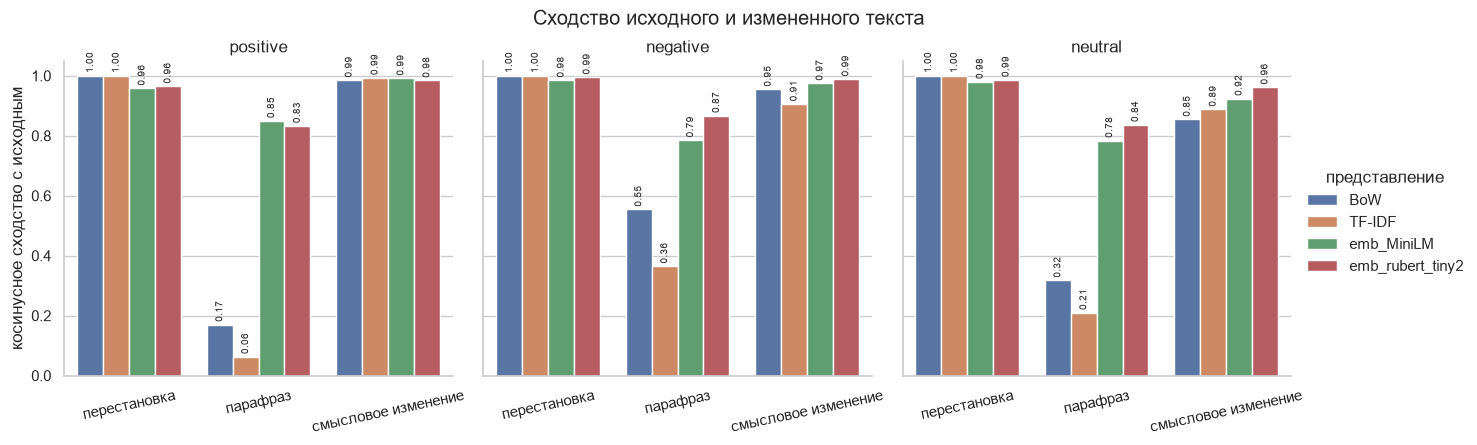

In [17]:
long = sims.melt(id_vars=["label", "transformation", "meaning_changed"], value_vars=SIM_COLS,
                 var_name="представление", value_name="cos")
order = ["перестановка", "парафраз", "смысловое изменение"]

g = sns.catplot(data=long, x="transformation", y="cos", hue="представление", col="label",
                kind="bar", order=order, col_order=["positive", "negative", "neutral"],
                height=4.2, aspect=1.05, palette="deep")
for ax in g.axes.flat:
    ax.set_ylim(0, 1.05); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=12)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", fontsize=7, rotation=90, padding=2)
g.set_titles("{col_name}"); g.set_axis_labels("", "косинусное сходство с исходным")
g.fig.suptitle("Сходство исходного и измененного текста", y=1.03)
plt.savefig(OUT_DIR / "similarity_bars.png", dpi=150, bbox_inches="tight"); plt.show()

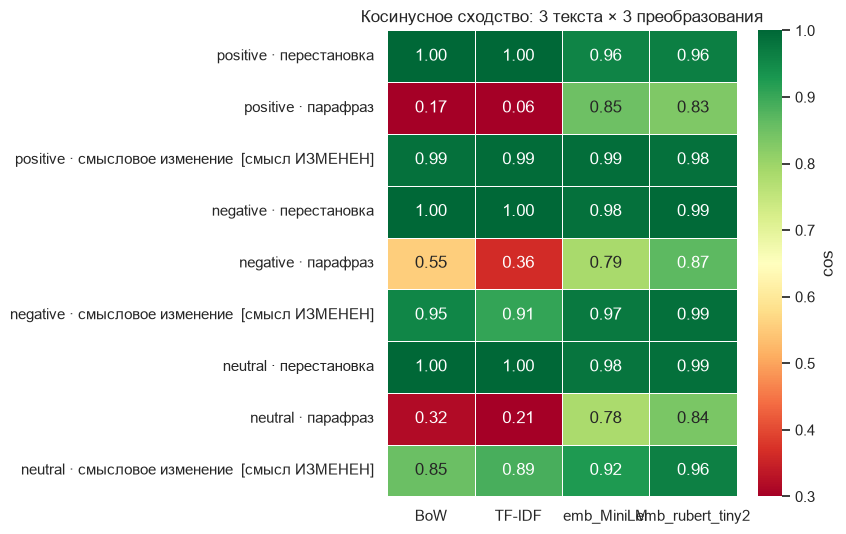

In [18]:
hm = sims.assign(pair=sims["label"] + " · " + sims["transformation"]
                 + np.where(sims["meaning_changed"] == "да", "  [смысл ИЗМЕНЕН]", ""))
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(hm.set_index("pair")[SIM_COLS], annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0.3, vmax=1, linewidths=.5, ax=ax, cbar_kws={"label": "cos"})
ax.set(title="Косинусное сходство: 3 текста × 3 преобразования", ylabel="", xlabel="")
plt.tight_layout(); plt.savefig(OUT_DIR / "similarity_heatmap.png", dpi=150); plt.show()

In [19]:
by_tr = sims.groupby("transformation")[SIM_COLS].mean().loc[order]
display(by_tr.round(3))

gap = (sims.groupby("meaning_changed")[SIM_COLS].mean().T
       .rename(columns={"нет": "смысл сохранен", "да": "смысл изменен"}))
gap["разрыв"] = gap["смысл сохранен"] - gap["смысл изменен"]
gap.round(3)

,BoW,TF-IDF,emb_MiniLM,emb_rubert_tiny2
transformation,,,,
перестановка,1.000,1.000,0.974,0.982
парафраз,0.347,0.212,0.806,0.845
смысловое изменение,0.931,0.929,0.963,0.978


meaning_changed,смысл изменен,смысл сохранен,разрыв
BoW,0.931,0.674,-0.258
TF-IDF,0.929,0.606,-0.323
emb_MiniLM,0.963,0.890,-0.073
emb_rubert_tiny2,0.978,0.914,-0.065


## 7. Где численная близость плохо согласуется со смыслом

Хорошее представление должно давать **высокое** сходство, если смысл сохранен, и **низкое**, если изменен.
Ниже автоматически отбираются пары, где порядок нарушен: смысл изменен, но сходство выше, чем у парафраза
того же текста (у которого смысл сохранен).

In [20]:
mis = []
for lab in T:
    s = sims[sims["label"] == lab].set_index("transformation")
    for rep in SIM_COLS:
        if s.loc["смысловое изменение", rep] > s.loc["парафраз", rep]:
            mis.append((lab, rep, "смысл изменен, но ближе парафраза",
                        f"изменение {s.loc['смысловое изменение', rep]:.3f} > парафраз {s.loc['парафраз', rep]:.3f}"))
mismatch = pd.DataFrame(mis, columns=["текст", "представление", "тип рассогласования", "числа"])
mismatch

,текст,представление,тип рассогласования,числа
0,positive,BoW,"смысл изменен, но ближе парафраза",изменение 0.985 > парафраз 0.170
1,positive,TF-IDF,"смысл изменен, но ближе парафраза",изменение 0.993 > парафраз 0.063
2,positive,emb_MiniLM,"смысл изменен, но ближе парафраза",изменение 0.991 > парафраз 0.850
3,positive,emb_rubert_tiny2,"смысл изменен, но ближе парафраза",изменение 0.984 > парафраз 0.833
4,negative,BoW,"смысл изменен, но ближе парафраза",изменение 0.955 > парафраз 0.554
5,negative,TF-IDF,"смысл изменен, но ближе парафраза",изменение 0.906 > парафраз 0.364
6,negative,emb_MiniLM,"смысл изменен, но ближе парафраза",изменение 0.974 > парафраз 0.785
7,negative,emb_rubert_tiny2,"смысл изменен, но ближе парафраза",изменение 0.989 > парафраз 0.867
8,neutral,BoW,"смысл изменен, но ближе парафраза",изменение 0.854 > парафраз 0.318
9,neutral,TF-IDF,"смысл изменен, но ближе парафраза",изменение 0.888 > парафраз 0.210


**Дополнительный контрольный пример** - перестановка, которая *меняет* смысл. В русском языке роли задаются
падежами, но в конструкциях с совпадающими формами (им. п. = вин. п.) порядок слов решает, кто субъект.

In [21]:
extra = [("Мать любит дочь.", "Дочь любит мать."),
         ("Курс доллара вырос, а рубль упал.", "Курс доллара упал, а рубль вырос.")]
rows = []
for a, b in extra:
    v = CountVectorizer(**vec_kw).fit([a, b])
    r = {"A": a, "B": b, "BoW": cos(v.transform([a]), v.transform([b]))}
    for k, enc in encoders.items():
        ea, eb = enc.encode([a, b], normalize_embeddings=True); r[k] = float(ea @ eb)
    rows.append(r)
pd.DataFrame(rows).round(3)

,A,B,BoW,emb_MiniLM,emb_rubert_tiny2
0,Мать любит дочь.,Дочь любит мать.,1.0,0.944,0.977
1,"Курс доллара вырос, а рубль упал.","Курс доллара упал, а рубль вырос.",1.0,0.986,0.999


## 8. Выводы

Итоговый анализ (какие изменения видит каждое представление и какие игнорирует) приведен в отчете `report.docx`;
ниже краткая сводка, которая пересчитывается вместе с ноутбуком.

In [22]:
summary = pd.DataFrame({
    "перестановка": by_tr.loc["перестановка"],
    "парафраз": by_tr.loc["парафраз"],
    "смысловое изменение": by_tr.loc["смысловое изменение"],
    "фон (случайный текст)": baseline.loc["среднее"],
}).round(3)
summary

,перестановка,парафраз,смысловое изменение,фон (случайный текст)
BoW,1.000,0.347,0.931,0.054
TF-IDF,1.000,0.212,0.929,0.022
emb_MiniLM,0.974,0.806,0.963,0.229
emb_rubert_tiny2,0.982,0.845,0.978,0.479
